# 匯入套件

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 視覺化模態特徵分布

/mnt/data/yihua/miniconda3/envs/MulEHR/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


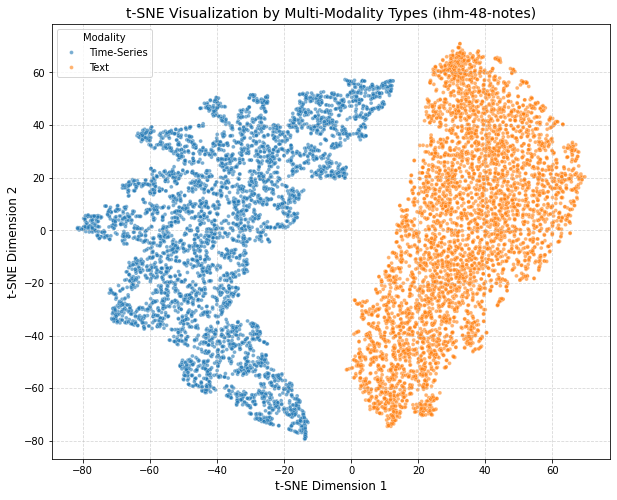

In [ ]:
task = 'ihm-48-notes'
filepath = f"/mnt/data/yihua/master/implementations/FuseMoE/src/run/TS_Text/{task}_TS_Text_TS_mTAND_64_Text_mTAND_64_layer1_moe_['laplace']_joint_[16, 5]_top_[4, 4]_batch_0.0004_8_8_128_1_2_512"

with open(os.path.join(filepath, 'sample_result.pkl'), 'rb') as f:
    result = pickle.load(f)

num_sample = result['features'].shape[0]
sub_sample_size = num_sample // 5
features = result['features'][:sub_sample_size]  # 原始特徵形狀: (N, Total_Dim)

# ==========================================
# 1. 定義模態名稱列表 (可自由增減)
# ==========================================
# 程式會自動根據列表長度去平分特徵維度
MODALITIES = ["Time-Series", "Text"] 
# 如果未來有三個模態，直接改為例如：["Time-Series", "Text", "Audio"]

num_modalities = len(MODALITIES)
total_dim = features.shape[1]

# 檢查是否能整除
if total_dim % num_modalities != 0:
    raise ValueError(f"特徵總維度 ({total_dim}) 無法被模態數量 ({num_modalities}) 整除，請檢查模態設定。")

# ==========================================
# 2. 自動切分與動態堆疊
# ==========================================
# np.split 會將特徵矩陣沿著直欄 (axis=1) 平均切分成 num_modalities 個子矩陣
split_features = np.split(features, num_modalities, axis=1)

split_features_list = []
modality_labels_list = []

for i, mod_name in enumerate(MODALITIES):
    # 取出切分後的單一模態特徵
    mod_feat = split_features[i]
    split_features_list.append(mod_feat)
    
    # 動態產生該模態的標籤
    mod_labels = [mod_name] * sub_sample_size
    modality_labels_list.append(mod_labels)

# 縱向堆疊所有模態的特徵與標籤
combined_features = np.vstack(split_features_list)
combined_labels = np.concatenate(modality_labels_list)

# ==========================================
# 3. 執行 t-SNE 降維
# ==========================================
tsne = TSNE(n_components=2, learning_rate='auto', init='pca', random_state=0, n_jobs=-1)
tsne_results = tsne.fit_transform(combined_features)

# 4. 建立 DataFrame
df = pd.DataFrame(
    {
        "t-SNE 1": tsne_results[:, 0],
        "t-SNE 2": tsne_results[:, 1],
        "Modality": combined_labels,
    }
)

# 5. 繪圖
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Modality",
    palette="tab10",  # tab10 顏色庫最多可完美支援 10 個不同的相異類別
    data=df,
    legend="full",
    alpha=0.6,
    s=15,
)

plt.title(f"t-SNE Visualization by Multi-Modality Types ({task})", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

output_dir = os.path.join(filepath, "images")
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "modality_visualization.png")
plt.savefig(output_path, transparent=False, facecolor='white')
plt.show()
plt.close()